# Problem Formulation: Predicting the Risk of Energy Poverty in Developing Areas

## Problem Statement

Globally, more than 700 million people do not have access to electricity, which is a major obstacle to advancements in education, healthcare, and the economy. Most of the current approaches to addressing energy poverty are reactive and rely on outdated annual surveys and reports that are unable to pinpoint the most important areas that require intervention.

Using historical economic, demographic, and infrastructure data from 1990 to 2020, we aim to forecast which nations will have energy poverty (electricity access <90%) between 2024 and 2027. In order to facilitate data-driven resource allocation by international development organizations, the model will categorize nations into three risk categories: severe, moderate, and minimal.

## Central Question

**Using historical trends in infrastructure development, demographic shifts, and economic indicators from 1990 to 2020, can we forecast which countries will face electricity access challenges?**

## Secondary questions
- Which variables—GDP, urbanization, and population density—correlate most strongly with a rise or drop in energy access?
- Is it possible to group nations into significant risk categories (severe, moderate, and minimal) in order to help prioritize tasks?

## Problem Type

This is essentially a **supervised learning problem** that combines:
- **Prediction**: Predicting the percentages of continuous electricity access
- **Classification**: classifying nations into risk categories for energy poverty
- **Exploration**: Finding the main underlying factors and trends in energy access

## Inputs (Features)

The following predictor variables from World Bank datasets will be used in the model:

*Economic Indicators:*
- GDP per capita (Current USD)

*Demographic Indicators:*
- Urban population (% of total)
- Rural population (% of total)
- Population density (persons/km²)
- Total population

*Structural Variables:*
- Year (1990-2023)
- Country/Region (ISO codes)

*Source: World Bank World Development Indicators*

## Time Horizon

**Training (80%):** 1990–2017 — model learns historical patterns from 28 years of data

**Validation (10%):** 2018–2020 — tune and adjust model hyperparameters without touching test data

**Test (10%):** 2021–2023 — final accuracy check, simulate real forecasting by predicting years the model has never seen

**Forecast Target:** 2024–2027 — true future predictions (one to four years ahead, no actual values exist yet to compare against)

## Outputs (Target Variable)

**Primary Output:** 
- Predicted rates of access to electricity (%) for each country in 2024–2027

**Classification Output:**
- Risk categories for energy poverty: Severe (<50%), Moderate (50-89%), Minimal (90-99%) 
 
**Actionable Outputs:** 
- Ranked list of the ten to twenty greatest risk nations that need intervention 
- The top three to five feature importances (which factors matter most) 
- Confidence intervals for every forecast 
- Regional trends and patterns

## Success Criteria

The project will be considered successful if:

1. **Prediction Accuracy**:  The model predicts risk categories with at least 75% classification accuracy on held-out test data.

2. **Temporal Validation**: Using a model trained on data from 1990 to 2017, the model can accurately predict electricity access rates in 2018–2020 (demonstrates true forecasting ability).

3. **Interpretability**: We are able to identify and define the top three to five characteristics that have the biggest impact on forecasts of energy poverty.

4. **Actionability**: The model generates a prioritized list of ten to fifteen nations that need immediate intervention, with a detailed explanation based on anticipated risk factors.


### Import required Libraries

In [1]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scipy
%pip install scikit-learn


import pandas as pd
from matplotlib import pyplot as plt 
import numpy as np
import sqlite3
import seaborn as sns
from scipy.spatial.distance import euclidean, pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Data Aquisition 
### Load raw dataset

In [2]:

electricity_access_df = pd.read_csv("data/raw/1.AccessToElectricityAPI_EG.ELC.ACCS.ZS_DS2_en_csv_v2_63/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_63.csv", skiprows=4)
gdp_df = pd.read_csv("data/raw/2.GDPAPI_NY.GDP.PCAP.CD_DS2_en_csv_v2_31/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_31.csv", skiprows=4)
urban_population_df = pd.read_csv("data/raw/3.UrbanAPI_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_608/API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_608.csv", skiprows=4)
rural_population_df = pd.read_csv("data/raw/4.RuralAPI_SP.RUR.TOTL.ZS_DS2_en_csv_v2_2502/API_SP.RUR.TOTL.ZS_DS2_en_csv_v2_2502.csv", skiprows=4)
population_density_df = pd.read_csv("data/raw/5.PopulationDensityAPI_EN.POP.DNST_DS2_en_csv_v2_275/API_EN.POP.DNST_DS2_en_csv_v2_275.csv", skiprows=4)
total_population_df = pd.read_csv("data/raw/6.TotalPopulationAPI_SP.POP.TOTL_DS2_en_csv_v2_7/API_SP.POP.TOTL_DS2_en_csv_v2_7.csv", skiprows=4)
renewable_energy_df = pd.read_csv("data/raw/7.RenewableEnergyAPI_EG.FEC.RNEW.ZS_DS2_en_csv_v2_1409/API_EG.FEC.RNEW.ZS_DS2_en_csv_v2_1409.csv", skiprows=4)
government_effectiveness_df = pd.read_csv("data/raw/8.GovernmentEffectivenessAPI_GE.EST_DS2_en_csv_v2_2683/API_GE.EST_DS2_en_csv_v2_2683.csv", skiprows=4)

# Display the first few rows of each dataset to verify successful loading
print("Electricity Access Dataset:")
print(electricity_access_df.head())
print("\nGDP Dataset:")
print(gdp_df.head())
print("\nUrban Population Dataset:")
print(urban_population_df.head())
print("\nRural Population Dataset:")
print(rural_population_df.head())
print("\nPopulation Density Dataset:")
print(population_density_df.head())
print("\nTotal Population Dataset:")
print(total_population_df.head())
print("\nRenewable Energy Consumption Dataset:")
print(renewable_energy_df.head())
print("\nGovernment Effectiveness Dataset:")
print(government_effectiveness_df.head())

Electricity Access Dataset:
                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                            Indicator Name  Indicator Code  1960  1961  1962  \
0  Access to electricity (% of population)  EG.ELC.ACCS.ZS   NaN   NaN   NaN   
1  Access to electricity (% of population)  EG.ELC.ACCS.ZS   NaN   NaN   NaN   
2  Access to electricity (% of population)  EG.ELC.ACCS.ZS   NaN   NaN   NaN   
3  Access to electricity (% of population)  EG.ELC.ACCS.ZS   NaN   NaN   NaN   
4  Access to electricity (% of population)  EG.ELC.ACCS.ZS   NaN   NaN   NaN   

   1963  1964  1965  ...        2016        2017        2018        2019  \
0   NaN   NaN   NaN  ...  100.000000  100.000000  100.000000  100.000000   
1   NaN   NaN   NaN  ...   38.859598   40.223744   43.03

### Check dataframe structure, column types, and missing values

In [3]:
# Check the structure and data types of each dataset
print("Electricity Access Dataset:")
print(electricity_access_df.info())
print("\nGDP Dataset:")
print(gdp_df.info())
print("\nUrban Population Dataset:")
print(urban_population_df.info())
print("\nRural Population Dataset:")
print(rural_population_df.info())
print("\nPopulation Density Dataset:")
print(population_density_df.info())
print("\nTotal Population Dataset:")
print(total_population_df.info())
print("\nRenewable Energy Consumption Dataset:")
print(renewable_energy_df.info())
print("\nGovernment Effectiveness Dataset:")
print(government_effectiveness_df.info())

Electricity Access Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 70 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 

In [4]:
# Quick overview of distributions and ranges of numerical data
print("Electricity Access Dataset:")
print(electricity_access_df.describe())
print("\nGDP Dataset:")
print(gdp_df.describe())
print("\nUrban Population Dataset:")
print(urban_population_df.describe())
print("\nRural Population Dataset:")
print(rural_population_df.describe())
print("\nPopulation Density Dataset:")
print(population_density_df.describe())
print("\nTotal Population Dataset:")
print(total_population_df.describe())
print("\nRenewable Energy Consumption Dataset:")
print(renewable_energy_df.describe())
print("\nGovernment Effectiveness Dataset:")
print(government_effectiveness_df.describe())

Electricity Access Dataset:
       1960  1961  1962  1963  1964  1965  1966  1967  1968  1969  ...  \
count   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
mean    NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
std     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
min     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
25%     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
50%     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
75%     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
max     NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   

             2016        2017        2018        2019        2020        2021  \
count  263.000000  263.000000  263.000000  263.000000  263.000000  263.000000   
mean    83.819459   84.566219   85.202457   85.759857   86.293403   86.855188   
std     25.496742   24.937006   24.083577   23.831564   23.429

In [5]:
# Inspect missing data and number of unique countries
print("Electricity Access Dataset:")
print(electricity_access_df.isnull().sum())
print(electricity_access_df['Country Code'].nunique())
print("\nGDP Dataset:")
print(gdp_df.isnull().sum())
print(gdp_df['Country Code'].nunique())
print("\nUrban Population Dataset:")
print(urban_population_df.isnull().sum())
print(urban_population_df['Country Code'].nunique())
print("\nRural Population Dataset:")
print(rural_population_df.isnull().sum())
print(rural_population_df['Country Code'].nunique())
print("\nPopulation Density Dataset:")
print(population_density_df.isnull().sum())
print(population_density_df['Country Code'].nunique())
print("\nTotal Population Dataset:")
print(total_population_df.isnull().sum())
print(total_population_df['Country Code'].nunique())
print("\nRenewable Energy Consumption Dataset:")
print(renewable_energy_df.isnull().sum())
print(renewable_energy_df['Country Code'].nunique())
print("\nGovernment Effectiveness Dataset:")
print(government_effectiveness_df.isnull().sum())
print(government_effectiveness_df['Country Code'].nunique())

Electricity Access Dataset:
Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              266
                 ... 
2021                3
2022                3
2023                3
2024              266
Unnamed: 69       266
Length: 70, dtype: int64
266

GDP Dataset:
Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              115
                 ... 
2021                8
2022                9
2023               15
2024               26
Unnamed: 69       266
Length: 70, dtype: int64
266

Urban Population Dataset:
Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960                1
                 ... 
2021                1
2022                1
2023                1
2024                1
Unnamed: 69       266
Length: 70, dtype: int64
266

Rural Population Dataset:
Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
196

## Data Aquisition II (Database Storage)

In [6]:
# Reshape datasets from wide to long format
electricity_access_df_long = electricity_access_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],
    var_name="year",
    value_name="electricity_access"
)
gdp_df_long = gdp_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],      
    var_name="year",
    value_name="gdp_per_capita"
)
urban_population_df_long = urban_population_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],  
    var_name="year",
    value_name="urban_population_percent"
)
rural_population_df_long = rural_population_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],
    var_name="year",
    value_name="rural_population_percent"
)
population_density_df_long = population_density_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],      
    var_name="year",
    value_name="population_density"
)
total_population_df_long = total_population_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],
    var_name="year",
    value_name="total_population"
)
renewable_energy_df_long = renewable_energy_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],  
    var_name="year",
    value_name="renewable_energy_percent"
)
government_effectiveness_df_long = government_effectiveness_df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Indicator Name",
        "Indicator Code"
    ],      
    var_name="year",
    value_name="government_effectiveness"
)
# Merge all datasets into a single dataframe for modeling

merged_df = electricity_access_df_long[['Country Name', 'Country Code', 'year', 'electricity_access']]
merged_df = merged_df.merge(gdp_df_long[['Country Name', 'Country Code', 'year', 'gdp_per_capita']], on=['Country Name', 'Country Code', 'year'], how='left')
merged_df = merged_df.merge(urban_population_df_long[['Country Name', 'Country Code', 'year', 'urban_population_percent']], on=['Country Name', 'Country Code', 'year'], how='left')
merged_df = merged_df.merge(rural_population_df_long[['Country Name', 'Country Code', 'year', 'rural_population_percent']], on=['Country Name', 'Country Code', 'year'], how='left')
merged_df = merged_df.merge(population_density_df_long[['Country Name', 'Country Code', 'year', 'population_density']], on=['Country Name', 'Country Code', 'year'], how='left')
merged_df = merged_df.merge(total_population_df_long[['Country Name', 'Country Code', 'year', 'total_population']], on=['Country Name', 'Country Code', 'year'], how='left')
merged_df = merged_df.merge(renewable_energy_df_long[['Country Name', 'Country Code', 'year', 'renewable_energy_percent']], on=['Country Name', 'Country Code', 'year'], how='left')
merged_df = merged_df.merge(government_effectiveness_df_long[['Country Name', 'Country Code', 'year', 'government_effectiveness']], on=['Country Name', 'Country Code', 'year'], how='left')

# Save the final merged dataset to a CSV file for modeling
merged_df.to_csv('data/raw/integrated_dataset.csv', index=False)

### Database Connection

In [7]:

# Create database connection
conn = sqlite3.connect("energy_poverty.db")
cursor = conn.cursor()

# Enable foreign keys
cursor.execute("PRAGMA foreign_keys = ON;")

# Drop tables if they already exist
cursor.execute("DROP TABLE IF EXISTS indicators;")
cursor.execute("DROP TABLE IF EXISTS countries;")

# Create countries table
cursor.execute("""
CREATE TABLE countries (
    country_code TEXT PRIMARY KEY,
    country_name TEXT NOT NULL
);
""")

# Create indicators table
cursor.execute("""
CREATE TABLE indicators (
    country_code TEXT,
    year INTEGER,

    electricity_access REAL,
    gdp_per_capita REAL,
    urban_population_percent REAL,
    rural_population_percent REAL,
    population_density REAL,
    total_population REAL,
    renewable_energy_percent REAL,
    government_effectiveness REAL,

    PRIMARY KEY (country_code, year),
    FOREIGN KEY (country_code)
        REFERENCES countries(country_code)
);
""")

conn.commit()

merged_df = merged_df.rename(columns={
    'Country Name': 'country_name',
    'Country Code': 'country_code'
})

# Extract unique countries
countries_df = merged_df[['country_code', 'country_name']].drop_duplicates()

countries_df.to_sql("countries", conn, if_exists="append", index=False)

# Insert indicator data
merged_df.drop(columns=['country_name']).to_sql(
    "indicators",
    conn,
    if_exists="append",
    index=False
)

# Verify data insertion by querying the database
cursor.execute("SELECT * FROM countries LIMIT 5")
print("Sample data from countries table:")
print(cursor.fetchall())
cursor.execute("SELECT * FROM indicators LIMIT 5")
print("Sample data from indicators table:")
print(cursor.fetchall())

cursor.execute("""
SELECT c.country_name, i.year, i.electricity_access
FROM indicators i
JOIN countries c
ON i.country_code = c.country_code
LIMIT 5;
""")

print("\nSample joined data:")
print(cursor.fetchall())
#Close the database connection
conn.close()    


Sample data from countries table:
[('ABW', 'Aruba'), ('AFE', 'Africa Eastern and Southern'), ('AFG', 'Afghanistan'), ('AFW', 'Africa Western and Central'), ('AGO', 'Angola')]
Sample data from indicators table:
[('ABW', 1960, None, None, 59.0236701687155, 40.9763298312845, None, 54922.0, None, None), ('AFE', 1960, None, 186.089204223988, 14.6403707377234, 85.3596292622766, None, 130075728.0, None, None), ('AFG', 1960, None, None, 8.12255149340207, 91.8774485065979, None, 9035043.0, None, None), ('AFW', 1960, None, 121.936832429715, 13.9464796319237, 86.0535203680763, None, 97630925.0, None, None), ('AGO', 1960, None, None, 10.3871038748875, 89.6128961251125, None, 5231654.0, None, None)]

Sample joined data:
[('Aruba', 1960, None), ('Africa Eastern and Southern', 1960, None), ('Afghanistan', 1960, None), ('Africa Western and Central', 1960, None), ('Angola', 1960, None)]


## Data Exploration
### Histogram

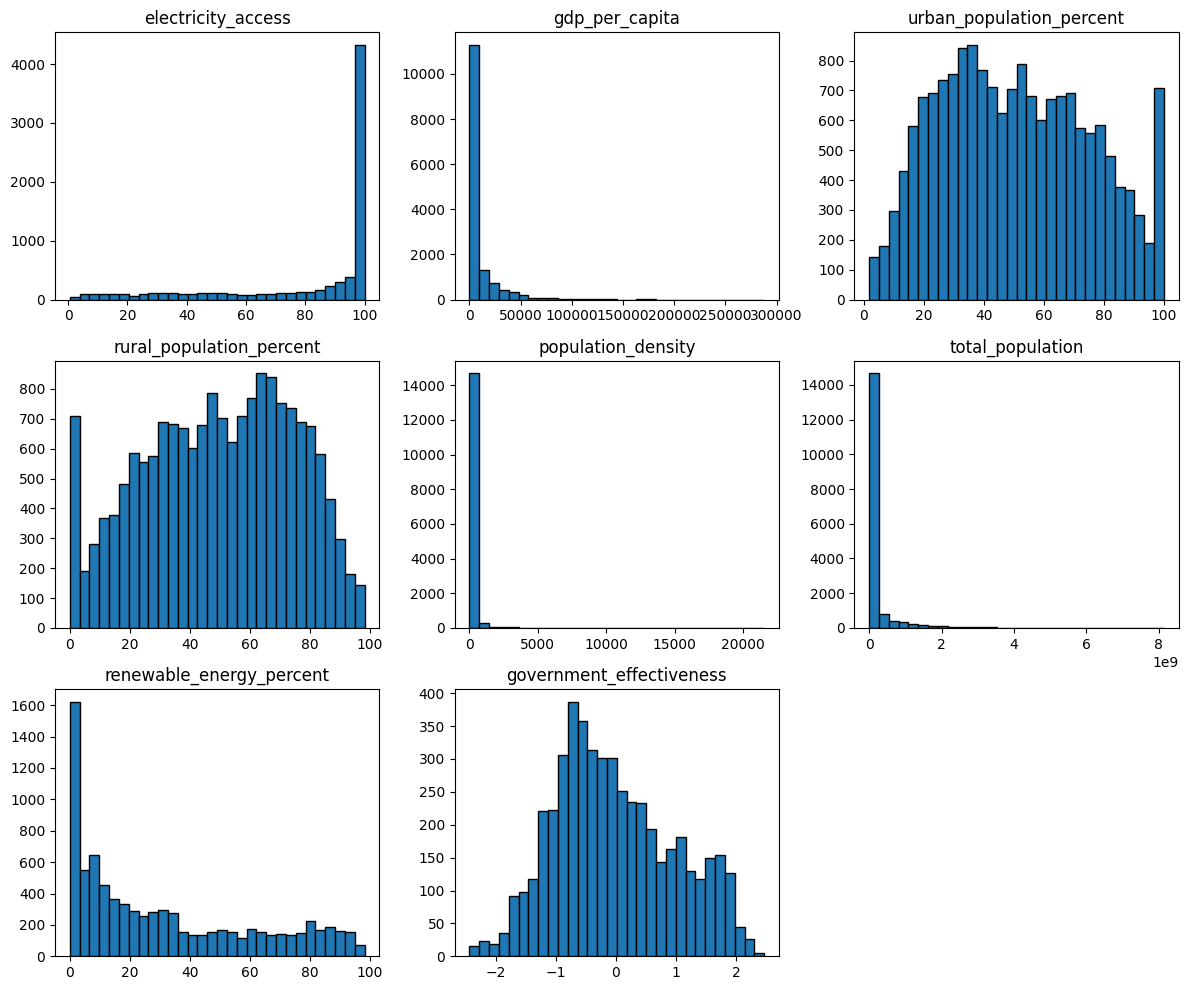

In [8]:
# Select only numeric columns (excluding year)
numeric_cols = merged_df.select_dtypes(include=['number']).columns.tolist()

# Remove 'year' from the list
if 'year' in numeric_cols:
    numeric_cols.remove('year')

# Create histograms with custom color
merged_df[numeric_cols].hist(
    figsize=(12, 10),
    bins=30,
    grid=False,
    edgecolor="black"
)

plt.tight_layout()
plt.show()


In [9]:
# Calculate skewness for all numeric columns to identify distribution asymmetry
merged_df.skew(numeric_only=True)

electricity_access         -1.389217
gdp_per_capita              4.661264
urban_population_percent    0.197213
rural_population_percent   -0.197213
population_density          9.742530
total_population            5.596873
renewable_energy_percent    0.734500
government_effectiveness    0.291337
dtype: float64

In [10]:
# Calculate kurtosis for all numeric columns to measure tail heaviness
merged_df.kurt(numeric_only=True)

electricity_access            0.535874
gdp_per_capita               33.963285
urban_population_percent     -0.908323
rural_population_percent     -0.908323
population_density          103.517160
total_population             37.901911
renewable_energy_percent     -0.801441
government_effectiveness     -0.654507
dtype: float64

### Scatter Plots

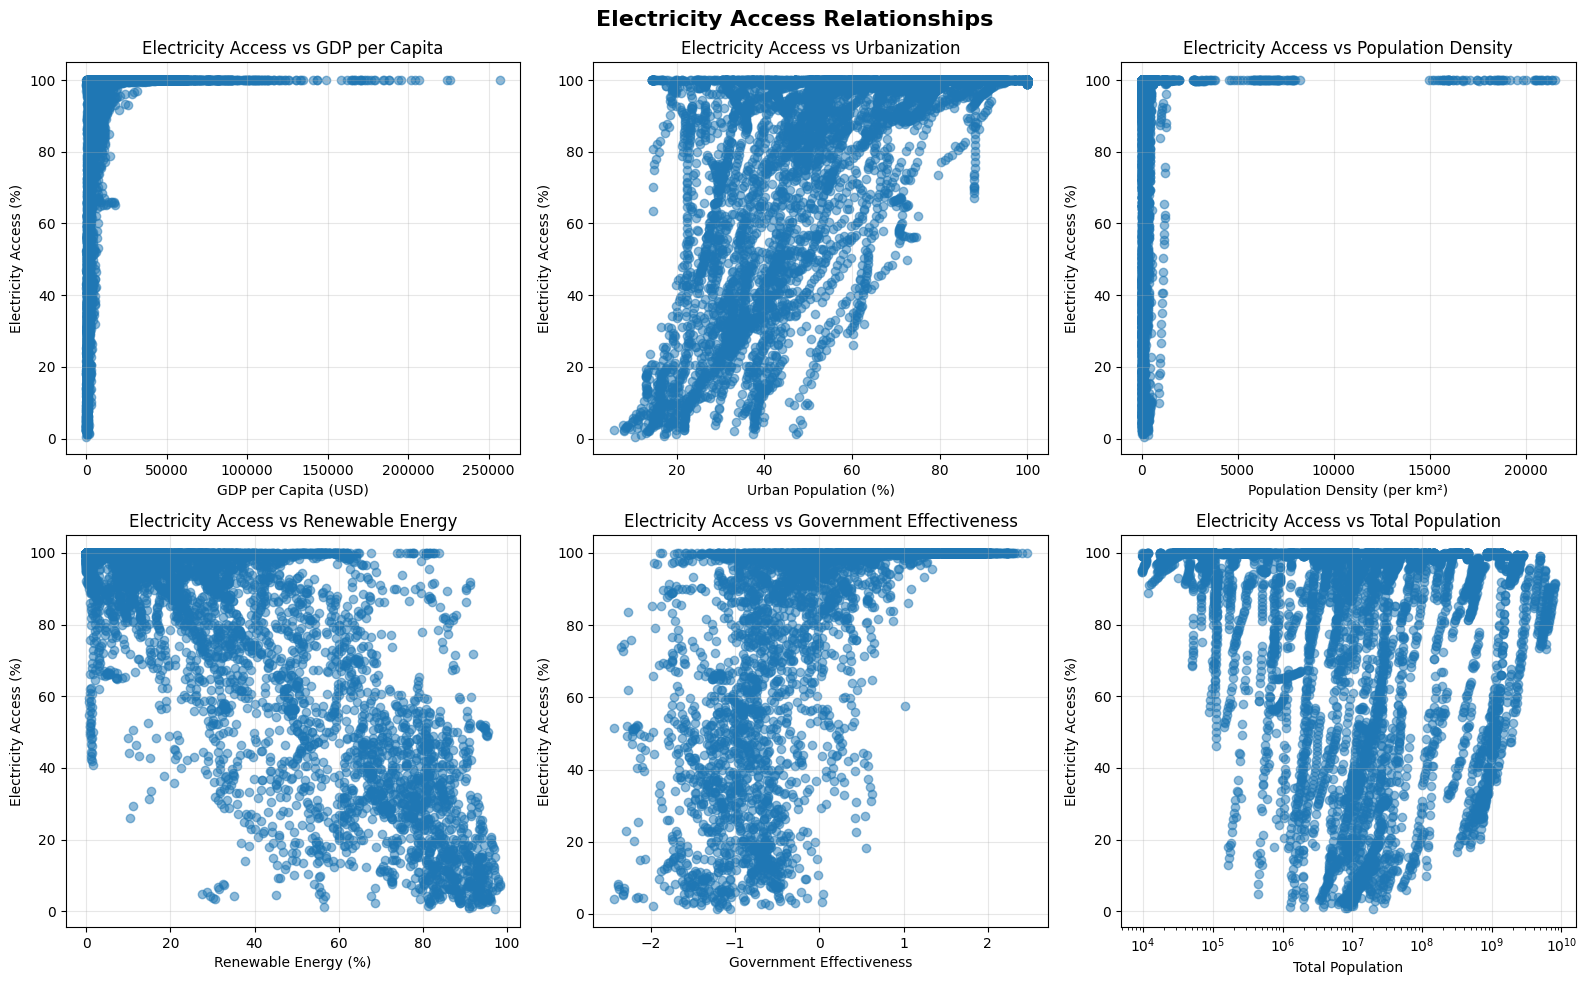

In [11]:
# Connect to database
conn = sqlite3.connect("energy_poverty.db")

# Load data
df_indicators = pd.read_sql_query("SELECT * FROM indicators", conn)
df_countries = pd.read_sql_query("SELECT * FROM countries", conn)

# Merge datasets
df = df_indicators.merge(df_countries, on='country_code', how='left')

# Create scatter plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Electricity Access Relationships', fontsize=16, fontweight='bold')

# Plot 1: GDP
axes[0, 0].scatter(df["gdp_per_capita"], df["electricity_access"], alpha=0.5)
axes[0, 0].set_xlabel("GDP per Capita (USD)")
axes[0, 0].set_ylabel("Electricity Access (%)")
axes[0, 0].set_title("Electricity Access vs GDP per Capita")
axes[0, 0].grid(alpha=0.3)

# Plot 2: Urbanization
axes[0, 1].scatter(df["urban_population_percent"], df["electricity_access"], alpha=0.5)
axes[0, 1].set_xlabel("Urban Population (%)")
axes[0, 1].set_ylabel("Electricity Access (%)")
axes[0, 1].set_title("Electricity Access vs Urbanization")
axes[0, 1].grid(alpha=0.3)

# Plot 3: Population Density
axes[0, 2].scatter(df["population_density"], df["electricity_access"], alpha=0.5)
axes[0, 2].set_xlabel("Population Density (per km²)")
axes[0, 2].set_ylabel("Electricity Access (%)")
axes[0, 2].set_title("Electricity Access vs Population Density")
axes[0, 2].grid(alpha=0.3)

# Plot 4: Renewable Energy
axes[1, 0].scatter(df["renewable_energy_percent"], df["electricity_access"], alpha=0.5)
axes[1, 0].set_xlabel("Renewable Energy (%)")
axes[1, 0].set_ylabel("Electricity Access (%)")
axes[1, 0].set_title("Electricity Access vs Renewable Energy")
axes[1, 0].grid(alpha=0.3)

# Plot 5: Government Effectiveness
axes[1, 1].scatter(df["government_effectiveness"], df["electricity_access"], alpha=0.5)
axes[1, 1].set_xlabel("Government Effectiveness")
axes[1, 1].set_ylabel("Electricity Access (%)")
axes[1, 1].set_title("Electricity Access vs Government Effectiveness")
axes[1, 1].grid(alpha=0.3)

# Plot 6: Total Population (log scale recommended)
axes[1, 2].scatter(df["total_population"], df["electricity_access"], alpha=0.5)
axes[1, 2].set_xlabel("Total Population")
axes[1, 2].set_ylabel("Electricity Access (%)")
axes[1, 2].set_title("Electricity Access vs Total Population")
axes[1, 2].set_xscale('log')  # Log scale for better visualization
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Close connection
conn.close()

### Correlation Matrix

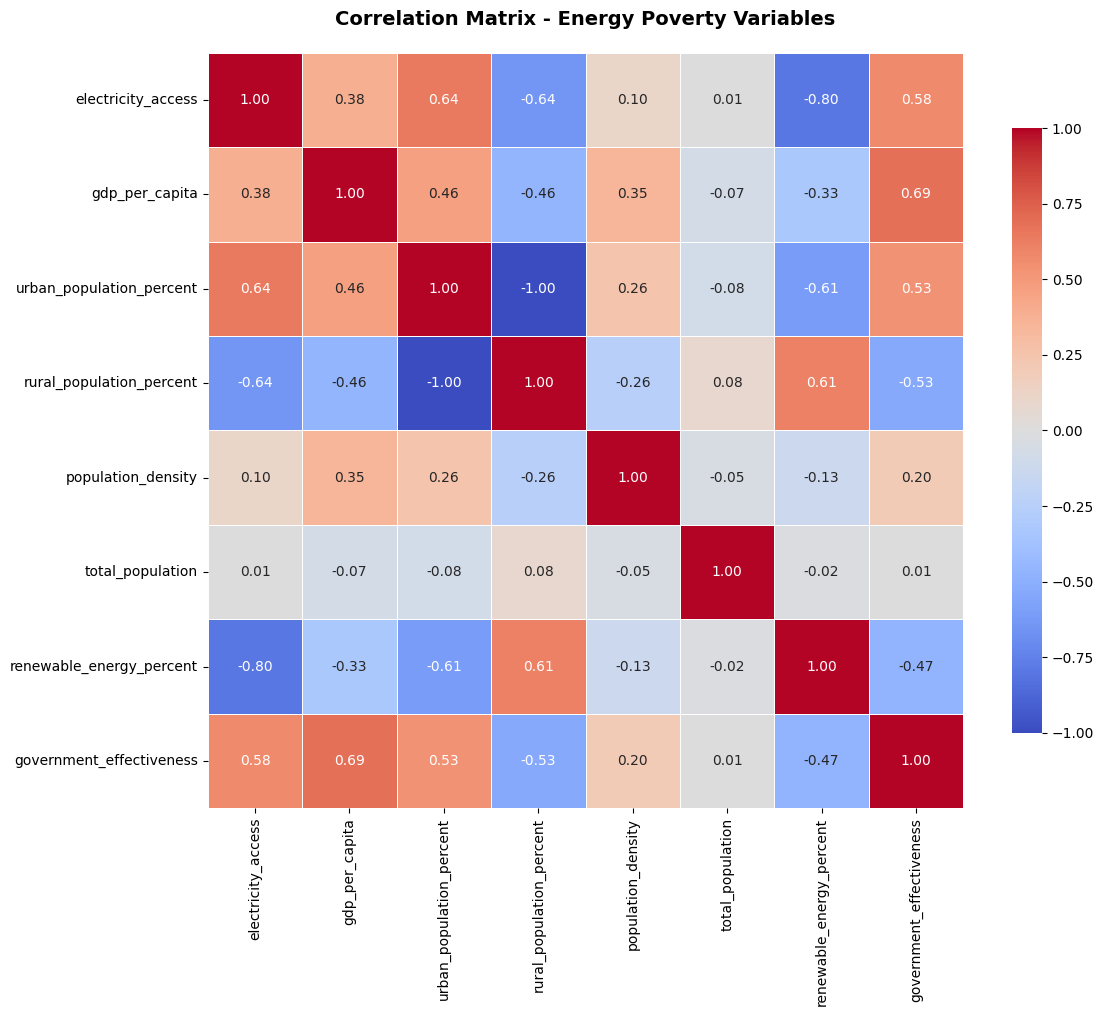

In [12]:
# Calculate correlation matrix (excluding year)
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'year' in numeric_cols:
    numeric_cols.remove('year')

corr = df[numeric_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, 
            annot=True,           # Show correlation values
            fmt='.2f',            # Format to 2 decimal places
            cmap='coolwarm',         # Grey colormap (matches your style)
            center=0,             # Center colormap at 0
            square=True,          # Square cells
            linewidths=0.5,       # Lines between cells
            cbar_kws={"shrink": 0.8})  # Colorbar size

plt.title("Correlation Matrix - Energy Poverty Variables", 
         fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [13]:
# Focus on correlations with electricity access (target variable)
target = "electricity_access"
correlations = corr[target].drop(target)
correlations_sorted = correlations.sort_values(ascending=False)

print("Correlations with Electricity Access:")
print("="*60)
print(correlations_sorted)

Correlations with Electricity Access:
urban_population_percent    0.642811
government_effectiveness    0.576522
gdp_per_capita              0.383428
population_density          0.103633
total_population            0.006319
rural_population_percent   -0.642811
renewable_energy_percent   -0.804609
Name: electricity_access, dtype: float64


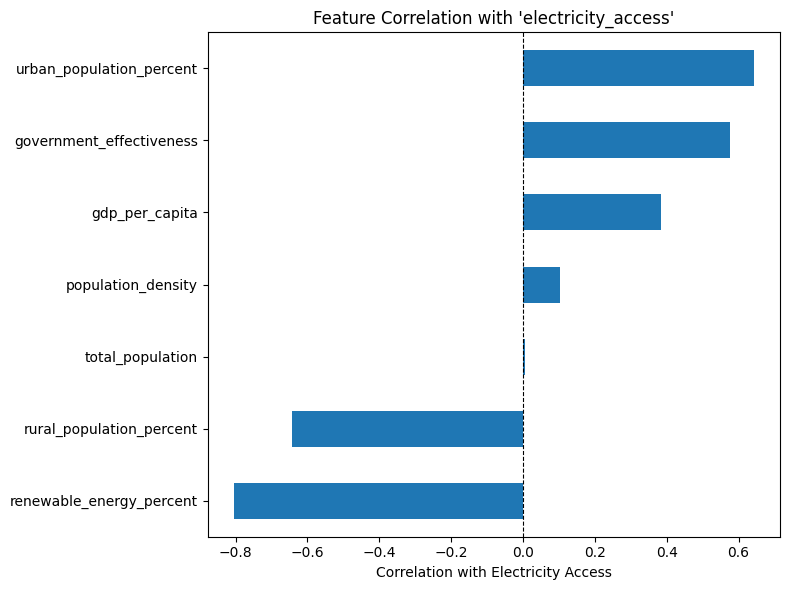

In [14]:
# Calculate correlation matrix
corr = df.corr(numeric_only=True)

# Set target variable 
target = "electricity_access"
correlations = corr[target].drop(target)
correlations.sort_values().plot(kind="barh", figsize=(8, 6))
plt.xlabel("Correlation with Electricity Access")
plt.title(f"Feature Correlation with '{target}'")
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

### Euclidean Distance

In [15]:
# Select features for comparison
feature_cols = ['gdp_per_capita', 'urban_population_percent', 
                'population_density', 'government_effectiveness']

# Get most recent year data for each country (2023)
df['year'] = pd.to_numeric(df['year'], errors='coerce')
latest_complete_year = df.dropna(subset=feature_cols)['year'].max()
df_recent = df[df['year'] == latest_complete_year]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_recent[feature_cols])

# Calculate pairwise distances
distances = pdist(X_scaled, metric='euclidean')
distance_matrix = squareform(distances)

# Create distance dataframe
distance_df = pd.DataFrame(
    distance_matrix,
    index=df_recent['country_name'].values,
    columns=df_recent['country_name'].values
)

# Find countries most similar to USA
if 'United States' in distance_df.index:
    similar_to_usa = distance_df['United States'].sort_values().head(6)
    print("Countries most similar to United States:")
    print(similar_to_usa)

Countries most similar to United States:
United States    0.000000
Norway           0.636971
Australia        0.722409
Iceland          0.724733
Germany          0.861294
Qatar            0.877685
Name: United States, dtype: float64


### KDE histogram

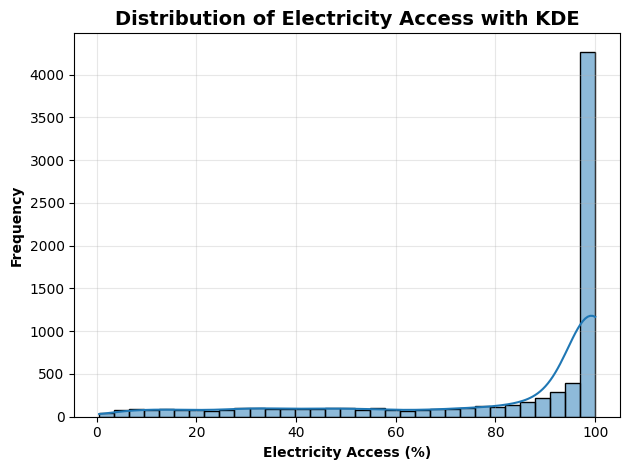

In [16]:

# Connect to your database
conn = sqlite3.connect("energy_poverty.db")

# Load the indicators table
df_indicators = pd.read_sql_query("SELECT * FROM indicators", conn)

# Create KDE histogram for electricity access
sns.histplot(df_indicators["electricity_access"], 
             kde=True,
             edgecolor='black')
plt.xlabel("Electricity Access (%)", fontweight='bold')
plt.ylabel("Frequency", fontweight='bold')
plt.title("Distribution of Electricity Access with KDE", fontweight='bold', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Close connection
conn.close()

### Box plot

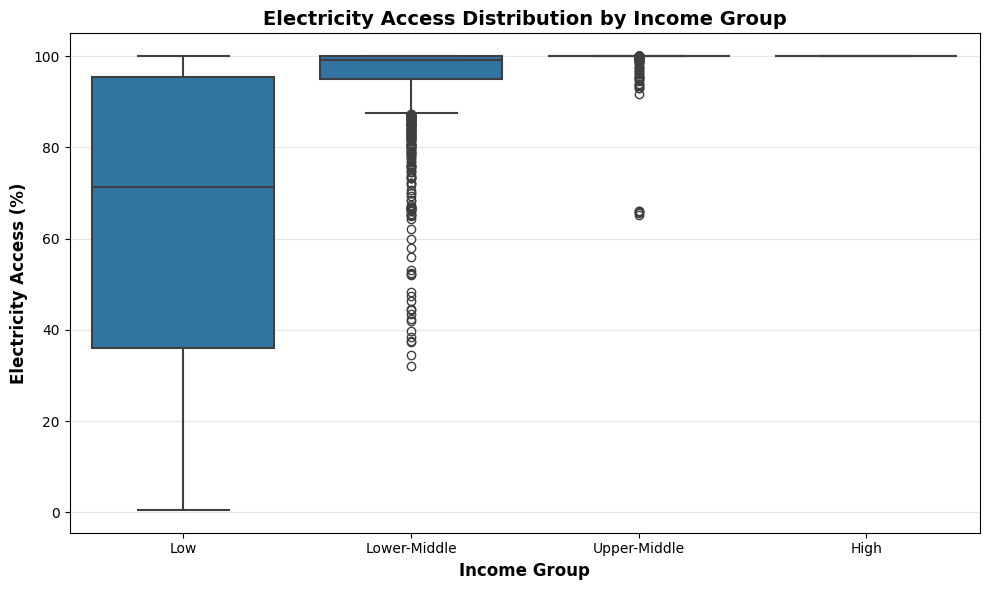

In [17]:
# Connect to database
conn = sqlite3.connect("energy_poverty.db")

# Load data
df_indicators = pd.read_sql_query("SELECT * FROM indicators", conn)
df_countries = pd.read_sql_query("SELECT * FROM countries", conn)

# Merge datasets
df = df_indicators.merge(df_countries, on='country_code', how='left')

# Create income categories based on GDP per capita
df['income_group'] = pd.cut(df['gdp_per_capita'], 
                            bins=[0, 5000, 15000, 50000, 300000],
                            labels=['Low', 'Lower-Middle', 'Upper-Middle', 'High'])

# Box plot: Electricity Access by Income Group
plt.figure(figsize=(10, 6))
sns.boxplot(x="income_group", y="electricity_access", data=df, linewidth=1.5)
plt.xlabel('Income Group', fontweight='bold', fontsize=12)
plt.ylabel('Electricity Access (%)', fontweight='bold', fontsize=12)
plt.title('Electricity Access Distribution by Income Group', 
         fontweight='bold', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

conn.close()

### Scatter Plots

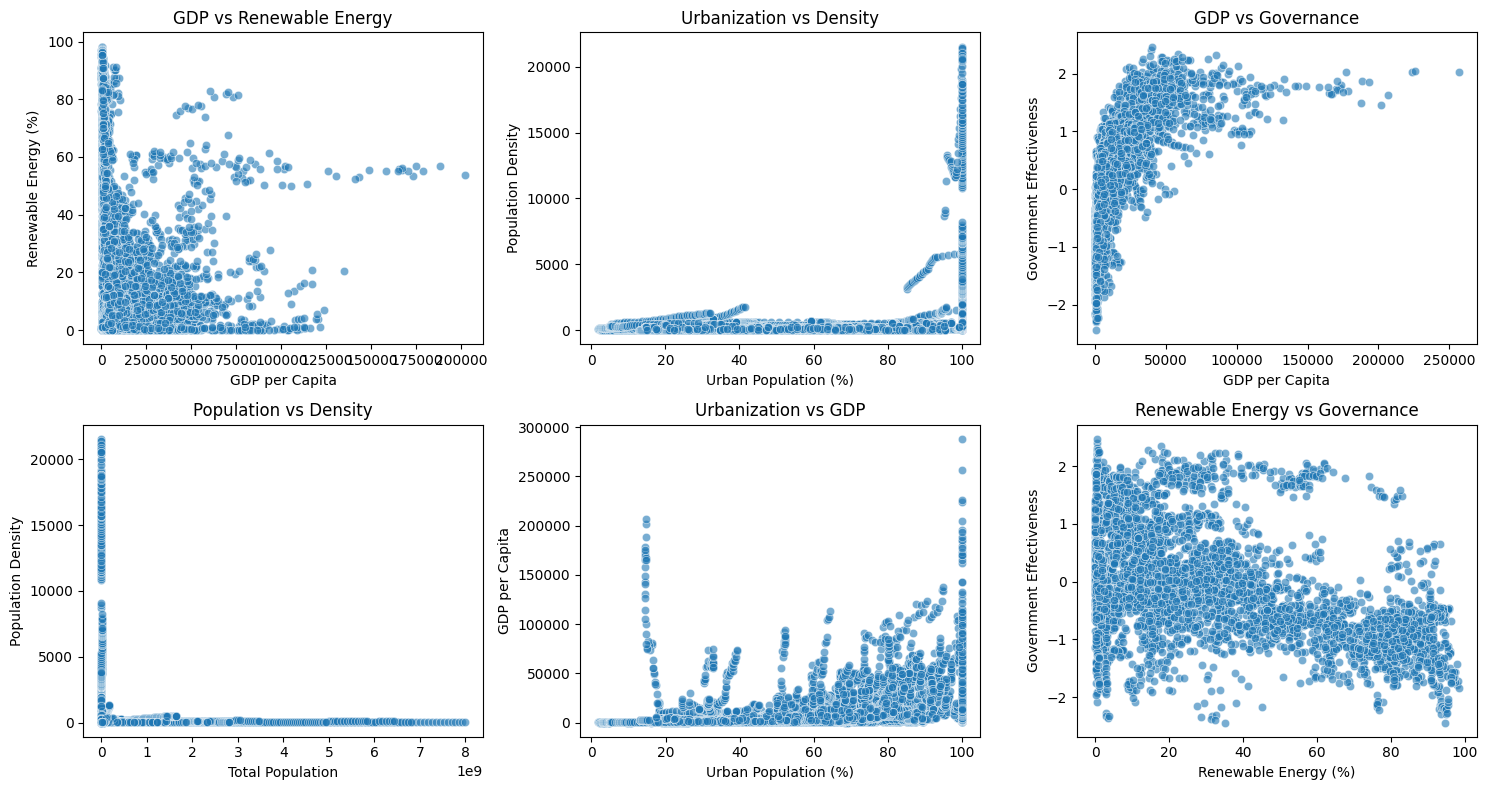

In [18]:
# Create scatter plots to explore relationships between key variables
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Scatter Plot 1: GDP per capita vs Renewable Energy %
sns.scatterplot(
    x="gdp_per_capita",
    y="renewable_energy_percent",
    data=df,
    alpha=0.6,
    ax=axes[0, 0]
)
axes[0, 0].set_xlabel("GDP per Capita")
axes[0, 0].set_ylabel("Renewable Energy (%)")
axes[0, 0].set_title("GDP vs Renewable Energy")

# Scatter Plot 2: Urban Population % vs Population Density
sns.scatterplot(
    x="urban_population_percent",
    y="population_density",
    data=df,
    alpha=0.6,
    ax=axes[0, 1]
)
axes[0, 1].set_xlabel("Urban Population (%)")
axes[0, 1].set_ylabel("Population Density")
axes[0, 1].set_title("Urbanization vs Density")

# Scatter Plot 3: GDP per capita vs Government Effectiveness
sns.scatterplot(
    x="gdp_per_capita",
    y="government_effectiveness",
    data=df,
    alpha=0.6,
    ax=axes[0, 2]
)
axes[0, 2].set_xlabel("GDP per Capita")
axes[0, 2].set_ylabel("Government Effectiveness")
axes[0, 2].set_title("GDP vs Governance")

# PScatter Plot 4: Total Population vs Population Density
sns.scatterplot(
    x="total_population",
    y="population_density",
    data=df,
    alpha=0.6,
    ax=axes[1, 0]
)
axes[1, 0].set_xlabel("Total Population")
axes[1, 0].set_ylabel("Population Density")
axes[1, 0].set_title("Population vs Density")

# Scatter Plot 5: Urban Population % vs GDP per capita
sns.scatterplot(
    x="urban_population_percent",
    y="gdp_per_capita",
    data=df,
    alpha=0.6,
    ax=axes[1, 1]
)
axes[1, 1].set_xlabel("Urban Population (%)")
axes[1, 1].set_ylabel("GDP per Capita")
axes[1, 1].set_title("Urbanization vs GDP")

# Scatter Plot 6: Renewable Energy % vs Government Effectiveness
sns.scatterplot(
    x="renewable_energy_percent",
    y="government_effectiveness",
    data=df,
    alpha=0.6,
    ax=axes[1, 2]
)
axes[1, 2].set_xlabel("Renewable Energy (%)")
axes[1, 2].set_ylabel("Government Effectiveness")
axes[1, 2].set_title("Renewable Energy vs Governance")

plt.tight_layout()
plt.show()

### Pair Plot

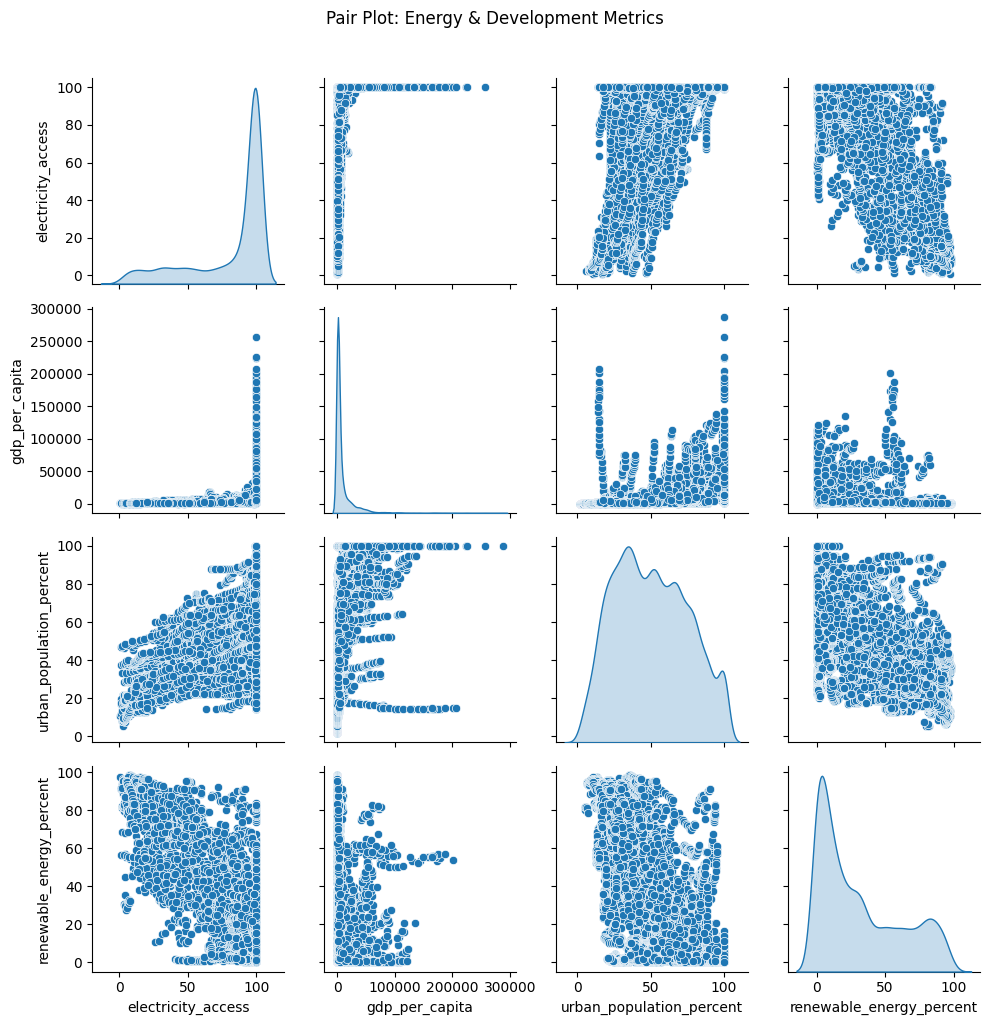

In [19]:
# Create pair plot for selected variables
selected_cols = [
    "electricity_access", 
    "gdp_per_capita", 
    "urban_population_percent", 
    "renewable_energy_percent"
]

sns.pairplot(df[selected_cols], diag_kind="kde")
plt.suptitle("Pair Plot: Energy & Development Metrics", y=1.02)
plt.tight_layout()
plt.show()

### PCA Projection

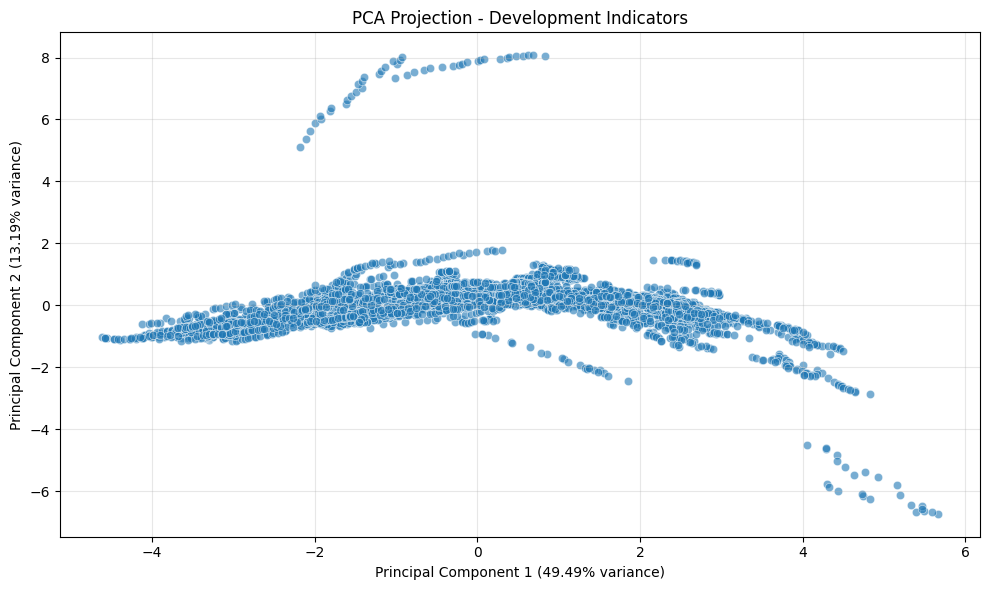

PC1 explains 49.49% of variance
PC2 explains 13.19% of variance
Total variance explained: 62.68%


In [20]:
# Select numeric features (drop non-numeric columns)

features = df.select_dtypes(include="number").drop(columns=["year"], errors="ignore")

# Remove rows with missing values
features = features.dropna()

# Standardize the features
X_scaled = StandardScaler().fit_transform(features)

# Apply PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], alpha=0.6)
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.title("PCA Projection - Development Indicators")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print explained variance
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.2%} of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]:.2%} of variance")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")